# ***EE5180 Course Contest***

## Ranjith.V.R (Rollno : EE23Z031, EMPID : IC37309)


In [ ]:
!pip install category_encoders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import category_encoders as ce
import matplotlib.pyplot as plt
train_data=pd.read_csv(r'/content/Insurance_Train.csv')
test_data=pd.read_csv(r'/content/Insurance_Test.csv')

# The Train data contains 5 non categorical and 8 categorical data

In [ ]:
train_data

,id,age,job,marital,education,balance,housing,loan,contact,month,duration,campaign,pdays,previous,poutcome,y
0,98749,32,admin.,single,secondary,64,yes,no,unknown,may,202,2,-1,0,unknown,0
1,19550,45,blue-collar,married,secondary,534,no,no,cellular,aug,104,6,-1,0,unknown,0
2,75084,45,technician,married,secondary,1477,yes,no,cellular,nov,75,1,132,1,failure,0
3,65715,39,technician,married,tertiary,14,no,no,cellular,jan,114,2,-1,0,unknown,0
4,41412,49,blue-collar,single,unknown,2222,no,no,unknown,jun,114,2,-1,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40684,24953,29,technician,single,secondary,3313,yes,no,unknown,jun,18,3,-1,0,unknown,0
40685,34002,59,admin.,married,secondary,92,yes,no,cellular,may,139,2,350,1,failure,0
40686,76035,54,blue-collar,married,secondary,548,no,no,cellular,aug,520,7,-1,0,unknown,1
40687,61279,46,blue-collar,married,primary,258,yes,no,unknown,may,217,1,-1,0,unknown,0


# **Preprocessing Train and Test Data**
# 1.Checking for Null And NA values

In [ ]:
null_na_count=pd.DataFrame([train_data.isnull().sum(), train_data.isna().sum(),test_data.isnull().sum(),test_data.isna().sum()])
null_na_count=null_na_count.T
null_na_count.columns=['Train Null','Train NA','Test Null','Test NA']
null_na_count

,Train Null,Train NA,Test Null,Test NA
id,0.0,0.0,0.0,0.0
age,0.0,0.0,0.0,0.0
job,0.0,0.0,0.0,0.0
marital,0.0,0.0,0.0,0.0
education,0.0,0.0,0.0,0.0
balance,0.0,0.0,0.0,0.0
housing,0.0,0.0,0.0,0.0
loan,0.0,0.0,0.0,0.0
contact,0.0,0.0,0.0,0.0
month,0.0,0.0,0.0,0.0


#**2.Using Target encoding to encode Categorical** **features**
# # This is done by calculating the probability p(t = 1 | x = ci) in which t denotes the target, x is the input and ci is the i-th category

# # A function is written to check the data type of the feature and encode if has "object" type datatype.

In [ ]:
def preprocessor(train_data, test_data):
  tenc=ce.TargetEncoder()
  encoded_train_df=pd.DataFrame()
  encoded_test_df=pd.DataFrame()
  columns=train_data.columns
  for col in columns[:-1]:
    if train_data[col].dtype=='object':
      enc_col=tenc.fit_transform(train_data[col],train_data.iloc[:,-1])
      encoded_train_df[col]=enc_col.values
      enc_col=tenc.transform(test_data[col])
      encoded_test_df[col]=enc_col.values
    else:
      encoded_train_df[col]=train_data[col]
      encoded_test_df[col]=test_data[col]
  return encoded_train_df ,train_data.iloc[:,-1] , encoded_test_df

X_train,y_train,X_test=preprocessor(train_data, test_data)
X_test=X_test[X_train.columns]
train_id=X_train.iloc[:,0]
X_train=X_train.iloc[:,1:]


test_id=X_test.iloc[:,0]
X_test=X_test.iloc[:,1:]

# 3.Checking  , the mean and Standard deviation
# Using Standard scalar to standardize the features

# After normalizing the mean and std of features are close to zero and one

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


In [ ]:
X_train_scaled.describe()

,age,job,marital,education,balance,housing,loan,contact,month,duration,campaign,pdays,previous,poutcome
count,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04,4.068900e+04
mean,-3.082179e-16,5.137548e-16,2.245712e-15,2.116488e-16,3.283001e-17,2.711969e-16,1.581079e-15,3.065153e-16,1.278275e-16,-1.117617e-16,-2.759118e-17,1.047766e-17,1.571649e-18,1.840576e-16
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,-2.159401e+00,-1.024426e+00,-7.338532e-01,-1.363554e+00,-3.081122e+00,-8.958971e-01,-2.288201e+00,-1.569652e+00,-6.039365e-01,-1.000227e+00,-5.690188e-01,-4.123854e-01,-2.488395e-01,-2.486304e-01
25%,-7.476930e-01,-6.806651e-01,-7.338532e-01,-4.645287e-01,-4.234315e-01,-8.958971e-01,4.370246e-01,-1.569652e+00,-6.039365e-01,-6.008244e-01,-5.690188e-01,-4.123854e-01,-2.488395e-01,-2.486304e-01
50%,-1.830096e-01,-1.181822e-01,-7.338532e-01,-4.645287e-01,-2.996118e-01,-8.958971e-01,4.370246e-01,6.650212e-01,-1.929359e-01,-3.022420e-01,-2.465294e-01,-4.123854e-01,-2.488395e-01,-2.486304e-01
75%,6.640154e-01,4.604410e-01,1.545939e+00,1.404806e+00,2.225385e-02,1.116200e+00,4.370246e-01,6.650212e-01,-6.779512e-02,2.367575e-01,7.596005e-02,-4.123854e-01,-2.488395e-01,-2.486304e-01
max,5.087368e+00,3.902334e+00,1.545939e+00,1.404806e+00,3.309460e+01,1.116200e+00,4.370246e-01,6.650212e-01,4.801709e+00,1.807027e+01,1.942532e+01,8.286184e+00,1.172605e+02,5.294819e+00


## 4. Checking Correlation among features

<Axes: >

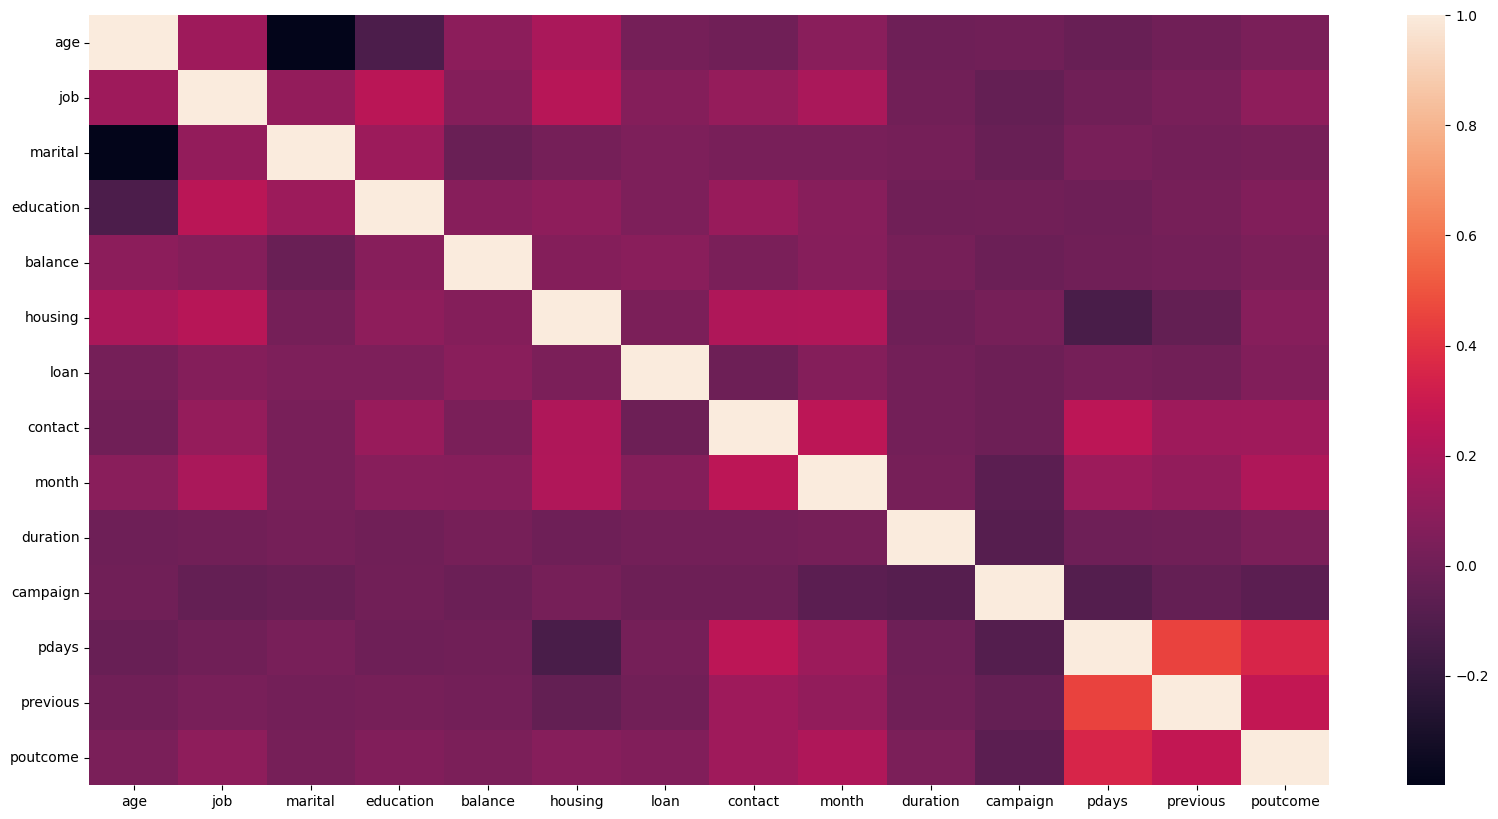

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
cor=X_train_scaled.corr()
plt.figure(figsize=(20,10))
sns.heatmap(cor, annot=False)

# Using K fold cross validation to check accuracy , precision , recall , f1 score.

In [ ]:
from sklearn.model_selection import cross_validate
def cross_validation(model, _X, _y, _cv=5):
      _scoring = ['accuracy', 'precision', 'recall', 'f1']
      results = cross_validate(estimator=model,
                               X=_X,
                               y=_y,
                               cv=_cv,
                               scoring=_scoring,
                               return_train_score=False)

      return {
                    "Validation Accuracy scores": results['test_accuracy'],
                    "Mean Validation Accuracy": results['test_accuracy'].mean()*100,
                    "Validation Precision scores": results['test_precision'],
                    "Mean Validation Precision": results['test_precision'].mean(),
                    "Validation Recall scores": results['test_recall'],
                    "Mean Validation Recall": results['test_recall'].mean(),
                    "Validation F1 scores": results['test_f1'],
                    "Mean Validation F1 Score": results['test_f1'].mean()
                    }


# Testing different classifer to check their performance

# 1.Logistic regression

In [ ]:
from sklearn import linear_model
logr = linear_model.LogisticRegression()
LR_cv=cross_validation(logr , X_train_scaled,y_train)
LR_cv

{'Validation Accuracy scores': array([0.89862374, 0.90206439, 0.90280167, 0.90341607, 0.90205235]),
 'Mean Validation Accuracy': 90.17916454252506,
 'Validation Precision scores': array([0.63039014, 0.65913758, 0.65753425, 0.666     , 0.65407555]),
 'Mean Validation Precision': 0.6534275028068489,
 'Validation Recall scores': array([0.32247899, 0.33718487, 0.35294118, 0.34978992, 0.34558824]),
 'Mean Validation Recall': 0.3415966386554622,
 'Validation F1 scores': array([0.4266852 , 0.44614315, 0.45933014, 0.45867769, 0.45223368]),
 'Mean Validation F1 Score': 0.44861397189799207}

# 2.KNN classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
KNC=KNeighborsClassifier()
KNC_cv=cross_validation(KNC , X_train_scaled,y_train)
KNC_cv

{'Validation Accuracy scores': array([0.89223396, 0.89432293, 0.89628901, 0.89444581, 0.89639916]),
 'Mean Validation Accuracy': 89.47381764355939,
 'Validation Precision scores': array([0.55813953, 0.56865672, 0.58653846, 0.57034796, 0.58195489]),
 'Mean Validation Precision': 0.5731275115396155,
 'Validation Recall scores': array([0.37815126, 0.40021008, 0.38445378, 0.3960084 , 0.40651261]),
 'Mean Validation Recall': 0.39306722689075635,
 'Validation F1 scores': array([0.45084534, 0.46979038, 0.46446701, 0.46745195, 0.47866419]),
 'Mean Validation F1 Score': 0.46624377363123004}

## 3.Gaussian Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
NB_cv=cross_validation(model , X_train_scaled,y_train)
NB_cv

{'Validation Accuracy scores': array([0.87613664, 0.8763824 , 0.87970017, 0.87982305, 0.88152882]),
 'Mean Validation Accuracy': 87.87142179606532,
 'Validation Precision scores': array([0.47154472, 0.47403846, 0.48667325, 0.4872549 , 0.49421965]),
 'Mean Validation Precision': 0.48274619598089313,
 'Validation Recall scores': array([0.48739496, 0.51785714, 0.51785714, 0.52205882, 0.53886555]),
 'Mean Validation Recall': 0.5168067226890756,
 'Validation F1 scores': array([0.47933884, 0.49497992, 0.50178117, 0.5040568 , 0.51557789]),
 'Mean Validation F1 Score': 0.4991469235432929}

## 4.Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DTC=DecisionTreeClassifier()
DTC_cv=cross_validation(DTC , X_train_scaled,y_train)
DTC_cv

{'Validation Accuracy scores': array([0.86999263, 0.86974687, 0.87281887, 0.87294175, 0.86997665]),
 'Mean Validation Accuracy': 87.10953545502548,
 'Validation Precision scores': array([0.447     , 0.44674556, 0.45959104, 0.45824847, 0.44990548]),
 'Mean Validation Precision': 0.45229811170927603,
 'Validation Recall scores': array([0.46953782, 0.47584034, 0.49579832, 0.47268908, 0.5       ]),
 'Mean Validation Recall': 0.48277310924369743,
 'Validation F1 scores': array([0.4579918 , 0.46083418, 0.47700859, 0.46535677, 0.47363184]),
 'Mean Validation F1 Score': 0.4669646377752959}

## 5. XGBoost Classifier
### Parameters chosen based on
# 1. checking the performance  and varying the number of iterations


In [ ]:
from xgboost import XGBClassifier
xgbc = XGBClassifier(n_estimators=69)
xgb_cv=cross_validation(xgbc , X_train_scaled,y_train)
xgb_cv


{'Validation Accuracy scores': array([0.90390759, 0.90734824, 0.90476776, 0.90525928, 0.90954897]),
 'Mean Validation Accuracy': 90.6166368861485,
 'Validation Precision scores': array([0.61971831, 0.64431487, 0.62553191, 0.63816794, 0.64958449]),
 'Mean Validation Precision': 0.6354635040046721,
 'Validation Recall scores': array([0.46218487, 0.46428571, 0.46323529, 0.43907563, 0.49264706]),
 'Mean Validation Recall': 0.46428571428571425,
 'Validation F1 scores': array([0.52948255, 0.53968254, 0.53228727, 0.52022402, 0.56033453]),
 'Mean Validation F1 Score': 0.5364021809917437}

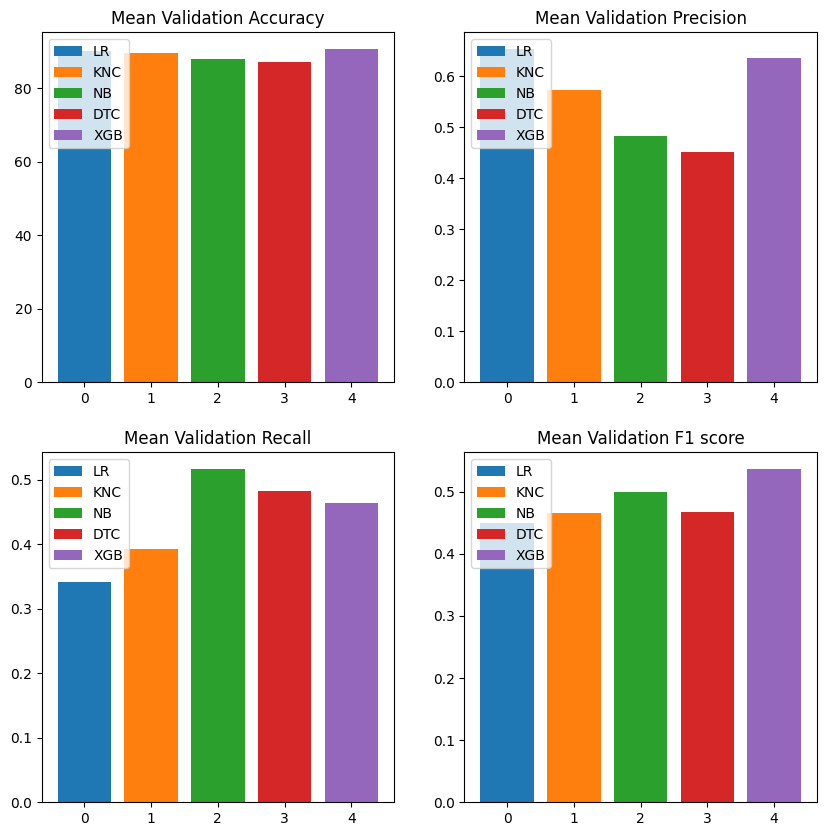

In [ ]:
count=0
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
classifier_name=['LR','KNC', 'NB', 'DTC','XGB']
for i in [LR_cv,KNC_cv, NB_cv , DTC_cv ,xgb_cv]:
    plt.title("Mean Validation Accuracy")
    plt.bar(count, list(i.values())[1], label=classifier_name[count])
    plt.legend(loc="upper left")
    count=count+1
plt.subplot(2,2,2)
classifier_name=['LR','KNC', 'NB', 'DTC','XGB']
count=0
for i in [LR_cv,KNC_cv, NB_cv , DTC_cv ,xgb_cv]:
    plt.title("Mean Validation Precision")
    plt.bar(count, list(i.values())[3], label=classifier_name[count])
    plt.legend(loc="upper left")
    count=count+1
plt.subplot(2,2,3)
classifier_name=['LR','KNC', 'NB', 'DTC','XGB']
count=0
for i in [LR_cv,KNC_cv, NB_cv , DTC_cv ,xgb_cv]:
    plt.title("Mean Validation Recall")
    plt.bar(count, list(i.values())[5], label=classifier_name[count])
    plt.legend(loc="upper left")
    count=count+1
plt.subplot(2,2,4)
classifier_name=['LR','KNC', 'NB', 'DTC','XGB']
count=0
for i in [LR_cv,KNC_cv, NB_cv , DTC_cv ,xgb_cv]:
    plt.title("Mean Validation F1 score")
    plt.bar(count, list(i.values())[7], label=classifier_name[count])
    plt.legend(loc="upper left")
    count=count+1
plt.show()

# Xgboost classifier performed better in terms of Accuracy , Precision and F1 score , so It was choosen as the final model

# Feature Selection

## Xgboost can automatically provide estimates of feature importance from a trained predictive model.

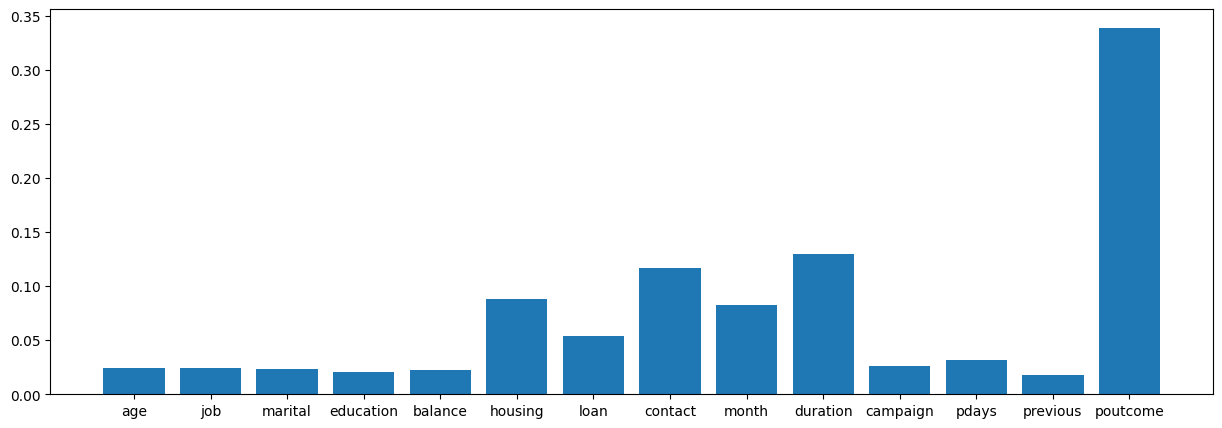

In [ ]:
xgbc.fit(X_train_scaled,y_train)
xgbc_predicted = xgbc.predict(X_test_scaled)
plt.figure(figsize=(15,5))
plt.bar(range(len(xgbc.feature_importances_)), xgbc.feature_importances_)
plt.xticks(range(len(xgbc.feature_importances_)),list( X_train_scaled.columns))
plt.show()

In [ ]:
result=pd.DataFrame([test_data['id'] ,xgbc_predicted])# ,columns=['id','y'])
result=result.T
result.columns=['id','y']
result.to_csv(r'/content/Submission_xgb_target_encoded_est_1.csv', index=False)

In [ ]:

result.shape
result['y'].value_counts()


0    4103
1     419
Name: y, dtype: int64

# Score in Kaggle
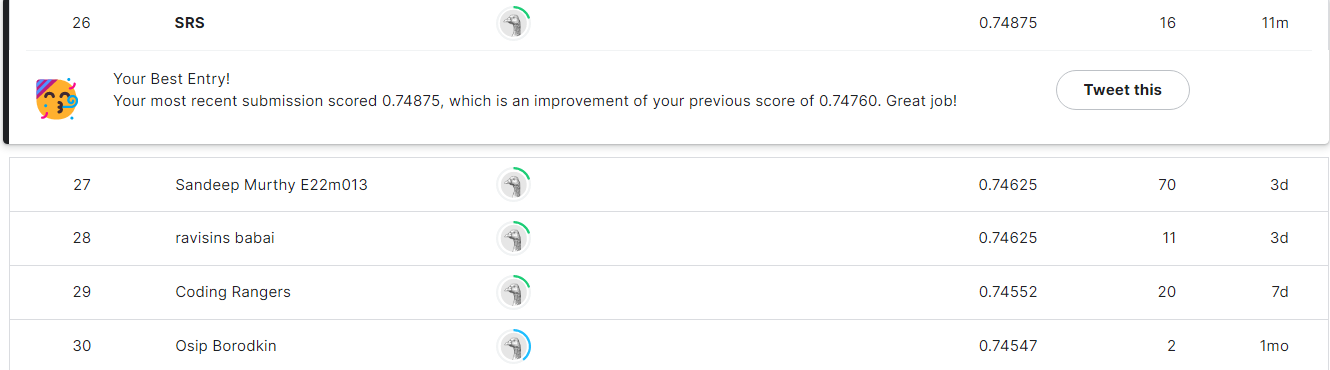